# A first EM algorithm

We ask one question. How can we estimate two distributions when we observe each value but not the group that produced it?

## Start from first principles

- $X_i$ is the observed weight of apple $i$ (**observed data**).
- $Z_i\in\{0,1\}$ is its unobserved variety (**latent variable**).
- Each variety has a Gaussian weight distribution (**probability model**).
- The two means, their shared variance, and the proportion of each variety are unknown (**parameters**).
- If every variety label were known, ordinary counting and averaging would give the maximum likelihood estimates (**complete data**).

This worked example connects **mixture distributions, latent variables, conditional probability, likelihood, and maximum likelihood estimation** with **expected counts, weighted means, and EM**.


## 1. Concept and intuition

A box contains two apple varieties with overlapping weight distributions. The variety stickers have been removed, so only the weights remain.

A light apple is more likely to come from variety 1, and a heavy apple is more likely to come from variety 2. Apples in the overlap remain uncertain. EM carries that uncertainty through the calculation as a probability.

The data below are simulated so that the answer can be checked. The true variety labels are retained only for that check.


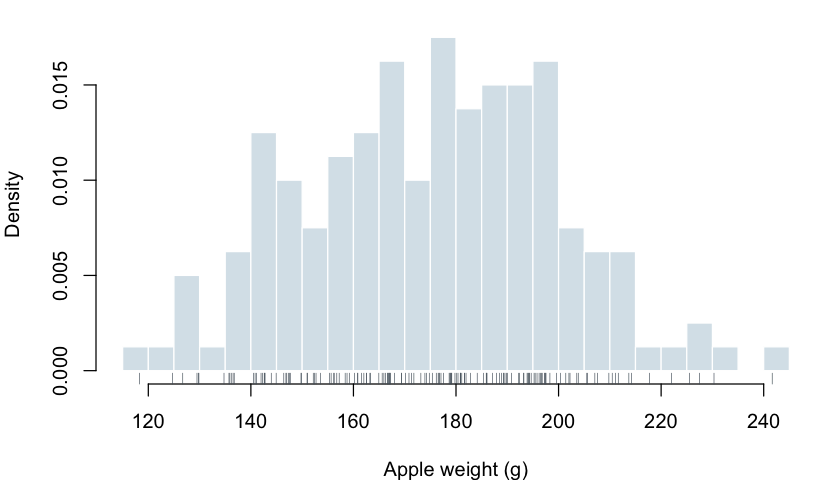

In [1]:
set.seed(8149)

n_apple <- 160L
true_parameter <- list(
  pi = 0.45,
  mu = c(150, 190),
  sigma = 16
)

true_variety <- sample(
  1:2, n_apple, replace = TRUE,
  prob = c(true_parameter$pi, 1 - true_parameter$pi)
)
weight <- rnorm(
  n_apple,
  mean = true_parameter$mu[true_variety],
  sd = true_parameter$sigma
)

options(repr.plot.width = 7, repr.plot.height = 4)
par(mar = c(4, 4, 1, 1))
hist(
  weight, breaks = 18, probability = TRUE,
  col = "#d9e4ea", border = "white",
  xlab = "Apple weight (g)", main = ""
)
rug(weight, col = "#4f5b66")

## 2. Write a probability model

Let $Z_i=1$ identify variety 1 and $Z_i=0$ identify variety 2. The model is

$$
P(Z_i=1)=\pi,
$$

$$
X_i\mid Z_i=1\sim N(\mu_1,\sigma^2),\qquad
X_i\mid Z_i=0\sim N(\mu_2,\sigma^2).
$$

The observed weight therefore has mixture density

$$
p(x_i\mid\theta)=\pi\,\phi(x_i;\mu_1,\sigma)
+(1-\pi)\,\phi(x_i;\mu_2,\sigma),
$$

where $\theta=(\pi,\mu_1,\mu_2,\sigma)$. The sum appears because either variety could have produced $x_i$.

If $Z_i$ were observed, the complete-data log likelihood would be

$$
\ell_c(\theta;X,Z)=\sum_i\left[
Z_i\{\log\pi+\log\phi(x_i;\mu_1,\sigma)\}
+(1-Z_i)\{\log(1-\pi)+\log\phi(x_i;\mu_2,\sigma)\}\right].
$$


## 3. E step: infer the missing labels

At iteration $t$, use the current parameters to calculate

$$
r_i^{(t)}
=P(Z_i=1\mid X_i=x_i,\theta^{(t)})
=\frac{\pi^{(t)}\phi(x_i;\mu_1^{(t)},\sigma^{(t)})}
{\pi^{(t)}\phi(x_i;\mu_1^{(t)},\sigma^{(t)})
+(1-\pi^{(t)})\phi(x_i;\mu_2^{(t)},\sigma^{(t)})}.
$$

$r_i^{(t)}$ is the conditional probability that apple $i$ belongs to variety 1. The probability for variety 2 is $1-r_i^{(t)}$. Since $E[Z_i\mid X_i,\theta^{(t)}]=r_i^{(t)}$, these probabilities are expected group counts contributed by one apple.


## 4. M step: update the parameters

EM forms the expected complete-data log likelihood

$$
Q(\theta\mid\theta^{(t)})
=E_{Z\mid X,\theta^{(t)}}\left[\ell_c(\theta;X,Z)\right],
$$

then maximizes it. For this Gaussian mixture, the updates are

$$
\pi^{(t+1)}=\frac{1}{n}\sum_i r_i^{(t)},
$$

$$
\mu_1^{(t+1)}=\frac{\sum_i r_i^{(t)}x_i}{\sum_i r_i^{(t)}},\qquad
\mu_2^{(t+1)}=\frac{\sum_i(1-r_i^{(t)})x_i}{\sum_i(1-r_i^{(t)})},
$$

$$
(\sigma^2)^{(t+1)}=\frac{1}{n}\sum_i\left[
r_i^{(t)}(x_i-\mu_1^{(t+1)})^2
+(1-r_i^{(t)})(x_i-\mu_2^{(t+1)})^2\right].
$$

The E step supplies fractional labels. The M step applies the same counting, averaging, and variance calculation that complete labels would permit.


In [2]:
responsibility <- function(x, pi, mu, sigma) {
  density_1 <- pi * dnorm(x, mean = mu[1], sd = sigma)
  density_2 <- (1 - pi) * dnorm(x, mean = mu[2], sd = sigma)
  density_1 / (density_1 + density_2)
}

observed_loglik <- function(x, pi, mu, sigma) {
  mixture_density <-
    pi * dnorm(x, mean = mu[1], sd = sigma) +
    (1 - pi) * dnorm(x, mean = mu[2], sd = sigma)
  sum(log(mixture_density))
}

em_update <- function(x, pi, mu, sigma) {
  r <- responsibility(x, pi, mu, sigma)
  updated_pi <- mean(r)
  updated_mu <- c(
    sum(r * x) / sum(r),
    sum((1 - r) * x) / sum(1 - r)
  )
  updated_variance <- mean(
    r * (x - updated_mu[1])^2 +
      (1 - r) * (x - updated_mu[2])^2
  )

  list(
    pi = updated_pi, mu = updated_mu,
    sigma = sqrt(updated_variance)
  )
}

In [3]:
fit_em <- function(x, start, tolerance = 1e-8, max_iter = 500L) {
  parameter <- start
  history <- data.frame(
    iteration = 0L, pi = parameter$pi,
    mu_1 = parameter$mu[1], mu_2 = parameter$mu[2],
    sigma = parameter$sigma,
    loglik = observed_loglik(
      x, parameter$pi, parameter$mu, parameter$sigma
    )
  )

  for (iteration in seq_len(max_iter)) {
    updated <- em_update(
      x, parameter$pi, parameter$mu, parameter$sigma
    )
    old_value <- c(parameter$pi, parameter$mu, parameter$sigma)
    new_value <- c(updated$pi, updated$mu, updated$sigma)
    parameter <- updated

    history <- rbind(
      history,
      data.frame(
        iteration = iteration, pi = parameter$pi,
        mu_1 = parameter$mu[1], mu_2 = parameter$mu[2],
        sigma = parameter$sigma,
        loglik = observed_loglik(
          x, parameter$pi, parameter$mu, parameter$sigma
        )
      )
    )

    if (max(abs(new_value - old_value)) < tolerance) break
  }

  parameter$responsibility <- responsibility(
    x, parameter$pi, parameter$mu, parameter$sigma
  )
  parameter$history <- history
  parameter
}

fit <- fit_em(
  weight,
  start = list(pi = 0.50, mu = c(140, 200), sigma = 25)
)

## 5. Read the fitted mixture

The fitted means describe the two weight distributions. The fitted mixing proportion estimates the fraction of variety 1. Each apple also receives a posterior probability for its variety.

Values near 0 or 1 indicate strong evidence for one variety. Values near $1/2$ preserve uncertainty for apples in the overlap.


In [4]:
data.frame(
  parameter = c("pi", "mu_1", "mu_2", "sigma"),
  true_value = c(
    true_parameter$pi, true_parameter$mu, true_parameter$sigma
  ),
  estimate = round(c(fit$pi, fit$mu, fit$sigma), 2)
)

overlap <- order(abs(fit$responsibility - 0.5))[1:8]
data.frame(
  weight = round(weight[overlap], 1),
  probability_variety_1 = round(fit$responsibility[overlap], 3)
)

stopifnot(all(diff(fit$history$loglik) >= -1e-8))

parameter,true_value,estimate
<chr>,<dbl>,<dbl>
pi,0.45,0.44
mu_1,150.00,155.15
mu_2,190.00,190.06
sigma,16.00,17.11


weight,probability_variety_1
<dbl>,<dbl>
170.1,0.509
170.8,0.488
171.3,0.473
169.4,0.531
169.3,0.532
171.8,0.460
168.0,0.572
173.1,0.420


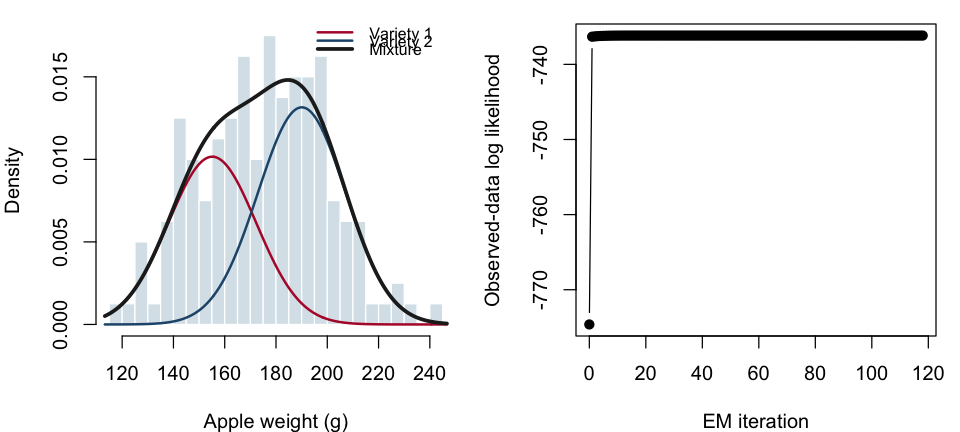

In [5]:
grid <- seq(min(weight) - 5, max(weight) + 5, length.out = 400)
component_1 <- fit$pi * dnorm(grid, fit$mu[1], fit$sigma)
component_2 <- (1 - fit$pi) * dnorm(grid, fit$mu[2], fit$sigma)

options(repr.plot.width = 8, repr.plot.height = 3.6)
par(mfrow = c(1, 2), mar = c(4, 4, 1, 1))
hist(
  weight, breaks = 18, probability = TRUE,
  col = "#d9e4ea", border = "white",
  xlab = "Apple weight (g)", main = ""
)
lines(grid, component_1, col = "#b31b34", lwd = 2)
lines(grid, component_2, col = "#24567a", lwd = 2)
lines(grid, component_1 + component_2, col = "#222222", lwd = 3)
legend(
  "topright", c("Variety 1", "Variety 2", "Mixture"),
  col = c("#b31b34", "#24567a", "#222222"),
  lwd = c(2, 2, 3), bty = "n", cex = 0.8
)
plot(
  fit$history$iteration, fit$history$loglik,
  type = "b", pch = 19,
  xlab = "EM iteration", ylab = "Observed-data log likelihood"
)
par(mfrow = c(1, 1))

## What to remember

1. **Concept and intuition.** A mixture distribution is simple when the group labels are known. Missing labels make the likelihood a sum over possible groups.
2. **Insight behind the approach.** The E step computes the conditional distribution of the latent variables. The M step maximizes the expected complete-data log likelihood.
3. **Worked example.** Apple weights give fractional variety assignments. Those probabilities become expected counts and weights for the usual maximum likelihood estimates.

The [genotyping-error example](P8149_Lecture_2_MAF_MLE_EM.ipynb) has the same structure. The latent variable becomes the true genotype, and the observed data become uncertain genotype measurements.

### Further reading

The apple data are constructed to keep the calculation visible.

- Dempster, Laird, and Rubin (1977), *Maximum Likelihood from Incomplete Data via the EM Algorithm*.
